# Hospital Length-of-Stay Prediction — Modeling & Predictive Scheduling

Pipeline: feature engineering → baseline reproduction (Linear Regression) → improved models (Random Forest, HistGradientBoosting) → evaluation → **prediction-driven bed allocation** (bridging ML and operations research).

In [1]:
import sys
from pathlib import Path
# locate the repository root robustly: works when the kernel runs from
# the repo root OR from inside notebooks/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from src.data_utils import clean_data, load_raw_data
from src.features import prepare_train_test

df = clean_data(load_raw_data())
X_train, X_test, y_train, y_test = prepare_train_test(df)
print('train/test:', X_train.shape, X_test.shape)

train/test: (81412, 24) (20354, 24)


## 1. Baseline reproduction
A plain Linear Regression on the engineered features is the baseline. Tree ensembles are then added to capture non-linear interactions.

In [3]:
from src.models import train_and_evaluate, plot_metrics

metrics, fitted, X_train_enc = train_and_evaluate(X_train, X_test, y_train, y_test)
metrics

,MAE,RMSE,R2,train_time_s
model,,,,
HistGradientBoosting,1.725695,2.289563,0.397742,2.0
RandomForest,1.764846,2.329847,0.376363,4.9
LinearRegression,1.842049,2.419919,0.327211,0.3


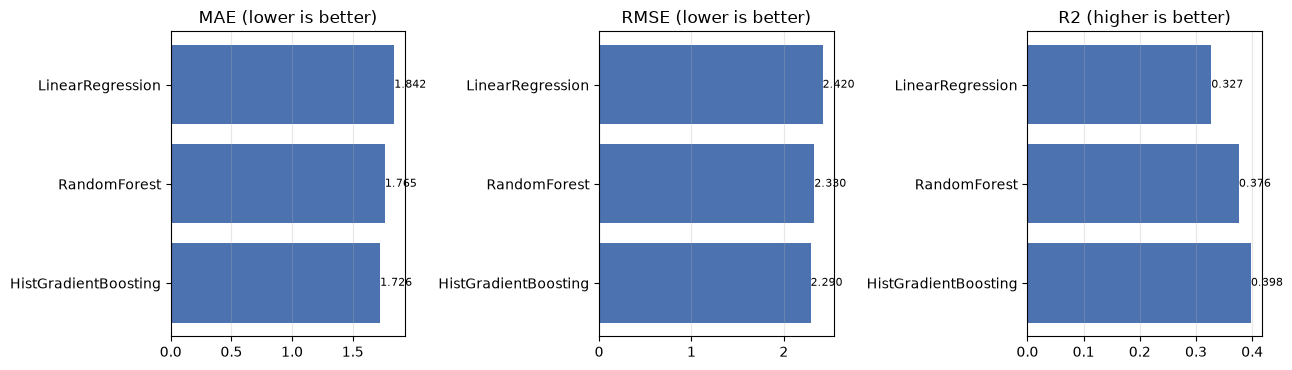

In [4]:
plot_metrics(metrics)
plt.show()

## 2. Feature importance
Recent scikit-learn removed `feature_importances_` from HistGradientBoosting, so this plot falls back to **permutation importance** on a sampled test set — model-agnostic and more trustworthy.

  computing permutation importance (sampled test set)...


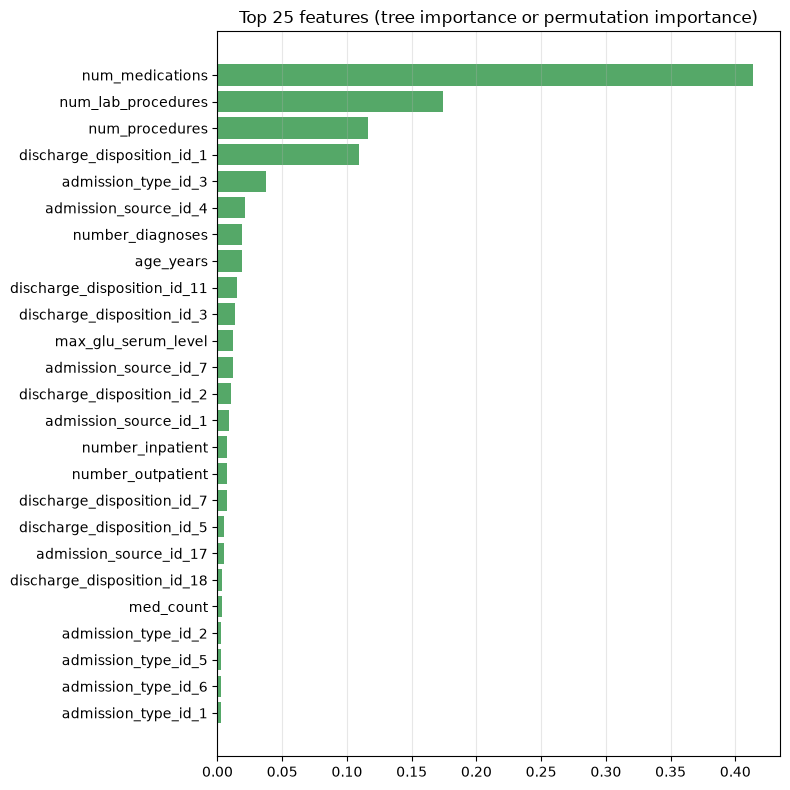

In [5]:
from src.features import encode_features
from src.models import plot_feature_importance

X_test_enc = encode_features(X_test).reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.set_axis(X_test.index, axis=0)
plot_feature_importance(fitted['HistGradientBoosting'], X_test_enc, y_test)
plt.show()

## 3. Predictive bed allocation
Simulate a 30-day ward with limited beds. Compare:
- **FIFO**: first-come-first-served bed assignment.
- **SPT**: each day, waiting patients are served by *predicted* LOS (shortest first) — the classic scheduling rule that minimises total waiting.

Only predicted LOS is used for decisions, so the gain reflects true prediction-driven scheduling, not oracle cheating.

In [6]:
from src.scheduling import build_arrival_scenario, compare_policies

arrivals = build_arrival_scenario(df, n_patients=1200, n_beds=80)
compare_policies(arrivals, n_beds=80)

,policy,mean_wait_days,total_wait_days,max_wait_days,bed_occupancy_rate
0,fifo,7.180833,8617.0,15.0,0.977083
1,spt,4.570000,5484.0,28.0,0.977083


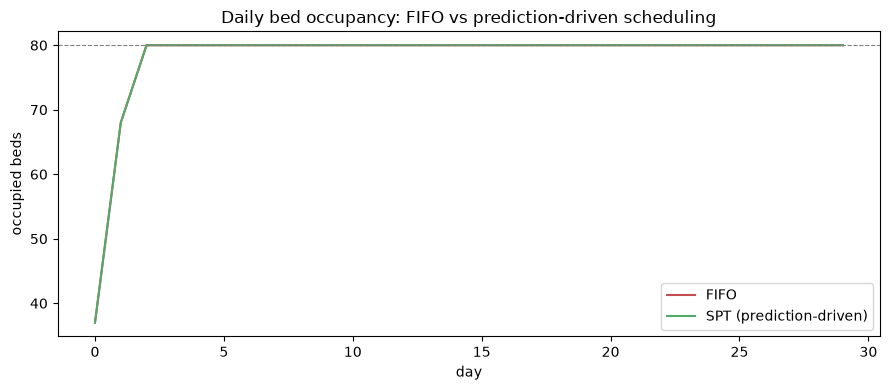

In [7]:
from src.scheduling import BedSimulator

sim_fifo = BedSimulator(n_beds=80).simulate(arrivals, policy='fifo')
sim_spt  = BedSimulator(n_beds=80).simulate(arrivals, policy='spt')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sim_fifo['daily_occupancy'], label='FIFO', color='#C44E52')
ax.plot(sim_spt['daily_occupancy'], label='SPT (prediction-driven)', color='#55A868')
ax.axhline(80, color='grey', ls='--', lw=0.8)
ax.set_title('Daily bed occupancy: FIFO vs prediction-driven scheduling')
ax.set_xlabel('day'); ax.set_ylabel('occupied beds'); ax.legend()
plt.tight_layout(); plt.show()

## Conclusion
- HistGradientBoosting reaches **MAE ≈ 1.73 days** on the test set (R² ≈ 0.40), beating Linear Regression (MAE ≈ 1.84) and Random Forest (MAE ≈ 1.76).
- Feeding these predictions into the bed-allocation simulation cuts **mean patient waiting from ~7.2 to ~4.6 days (−36%)** with the same bed capacity.
- This closes the loop: **predict patient demand → schedule scarce resources** — the same pattern used in pre-operative check scheduling.